# ╔════════════════════════════════════════════════════════════╗
# ║ 🍄 きのこ　🍄
# ╚════════════════════════════════════════════════════════════╝


# ===================== IMPORTS ======================

In [ ]:
# ═════════════════════ LOAD ═════════════════════
from pathlib import Path
import os

# ═════════════════════ SECTION ═════════════════════
import pandas as pd
import numpy as np

# ═════════════════════ VISUALIZATION TOOLS ═════════════════════
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image

# ═════════════════════ CNN ═════════════════════
from tensorflow.keras import Sequential, layers, optimizers, callbacks, regularizers
from tensorflow.keras.callbacks import EarlyStopping, CSVLogger
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.metrics import AUC
import tensorflow as tf

# ═════════════════════ OTHER ═════════════════════
from datetime import datetime
from tensorflow.keras.preprocessing.image import load_img, save_img, img_to_array

# ===================== PREPROCESSING ======================

In [ ]:
# # ░░░░░░░░░░░░░░ DATA AUGMENTATION (edible) ░░░░░░░░░░░░░░

# def augment_edible(edible_dir="data/image_dataset/edible"):
#     paths = list(Path(edible_dir).rglob("*.png"))

#     for p in paths:
#         save_img(str(p.parent / f"aug_{p.name}"), np.fliplr(img_to_array(load_img(p))))

# augment_edible()

# DO NOT RUN

In [ ]:
print(f"🍄 Edible: {len(list(Path('data/image_dataset/edible').rglob('*.jpg')) + list(Path('data/image_dataset/edible').rglob('*.png')))}")
print(f"☠️ Poisonous: {len(list(Path('data/image_dataset/poisonous').rglob('*.jpg')) + list(Path('data/image_dataset/poisonous').rglob('*.png')))}")

🍄 Edible: 2475
☠️ Poisonous: 5497


# =====================[■■■■■■■■■□] 90% LOADING ======================


In [ ]:
paths = list(Path("data/image_dataset/").rglob("*.png"))
df = pd.DataFrame({
    "path": paths,
    "label": [p.parent.name for p in paths]
})

# ===================== CONFIGURATION ======================

In [ ]:
# ░░ 💾 Save best model ░░
os.makedirs("models", exist_ok=True)
MODEL_1 = "models/model_1_{timestamp}.keras"
MODEL_2 = "models/augmented_1_{timestamp}.keras"

os.makedirs("logs", exist_ok=True)
timestamp = datetime.now().strftime("%d%m%Y_%H%M%S")

# ░░ 🏋 Training history logs ░░
csv_logger_1 = CSVLogger(f"logs/baseline_history_{timestamp}.csv")
csv_logger_2 = CSVLogger(f"logs/augmented_history_{timestamp}.csv")

# ===================== MODEL BASELINE ======================

In [ ]:
def initialize_baseline_model():
    baseline = Sequential([
        layers.Input(shape=(128, 128,3)),
        layers.Rescaling(1./255),

        layers.Conv2D(32, kernel_size = (4,4), padding="same", strides = (1,1), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPool2D(pool_size=(2,2), padding="same"),

        layers.Conv2D(64, kernel_size = (3,3), padding="same", strides = (1,1), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPool2D(pool_size=(2,2), padding="same"),

        layers.Conv2D(128, kernel_size = (3,3), padding="same", strides = (1,1), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPool2D(pool_size=(2,2), padding="same"),

        layers.Conv2D(512, kernel_size=(3,3), padding="same", activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPool2D(pool_size=(2,2), padding="same"),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),

        layers.Dense(1, activation="sigmoid")
    ])

    return baseline


In [ ]:
baseline = initialize_baseline_model()
baseline.summary()

Model: "sequential_52"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_54 (Rescaling)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_198 (Conv2D)             │ (None, 128, 128, 32)   │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_168         │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_198               │ (None, 64, 64, 32)     │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_199 (Conv2D)             │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_169         │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_199               │ (None, 32, 32, 64)     │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_200 (Conv2D)             │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_170         │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_200               │ (None, 16, 16, 128)    │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_201 (Conv2D)             │ (None, 16, 16, 512)    │       590,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_171         │ (None, 16, 16, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_201               │ (None, 8, 8, 512)      │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_26 (Flatten)            │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_104 (Dense)               │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_52 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_105 (Dense)               │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,881,761 (18.62 MB)

 Trainable params: 4,880,289 (18.62 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [ ]:
# ░░░░░░░░░░░░░░ Compilation ░░░░░░░░░░░░░░
adam = optimizers.Adam(learning_rate = 1e-4)

def compile_baseline_model(baseline):
    baseline.compile(
        loss = "binary_crossentropy",
        optimizer=adam,
        metrics = ["accuracy", "precision", "recall", AUC(name="auc")]
    )

    return baseline

In [ ]:
# ░░░░░░░░░░░░░░ Define data ░░░░░░░░░░░░░░
batch_size = 32

# We define a first one for the train data
train_ds = image_dataset_from_directory(
    "data/image_dataset",
    labels="inferred", # or class_names=["poisonous", "edible"]
    label_mode="binary",
    validation_split= 0.2,
    subset= "training",
    seed=123,
    image_size=(128, 128),
    batch_size=batch_size)

# We define a second one for the test data
val_ds = image_dataset_from_directory(
    "data/image_dataset",
    labels="inferred", # or class_names=["poisonous", "edible"]
    label_mode="binary",
    validation_split= 0.2,
    subset= "validation",
    seed=123,
    image_size=(128, 128),
    batch_size=batch_size)

Found 10447 files belonging to 2 classes.
Using 8358 files for training.
Found 10447 files belonging to 2 classes.
Using 2089 files for validation.


In [ ]:
# ░░░░░░░░░░░░░░ Inspect binary classification configuration ░░░░░░░░░░░░░░
class_names = train_ds.class_names
print(class_names)

['edible', 'poisonous']


In [ ]:
%%time

# ░░░░░░░░░░░░░░ Training ░░░░░░░░░░░░░░
baseline = initialize_baseline_model()
baseline = compile_baseline_model(baseline)

ES = EarlyStopping(
    patience=15,
    restore_best_weights=True
)

# ModelCheckpoint to save the best version of our model after every epoch
checkpoint = callbacks.ModelCheckpoint(MODEL,
                                            monitor="val_loss",
                                            verbose=0,
                                            save_best_only=True)

# ReduceLROnPlateau to reduce the learning_rate if the model doesn't get better after a few epochs
lr_reducer = callbacks.ReduceLROnPlateau(monitor="val_loss",
                                        factor=0.5,
                                        patience=3,
                                        verbose=1,
                                        min_lr=1e-6)

history = baseline.fit(
    train_ds,
    batch_size=32,
    epochs=10,
    validation_data=val_ds,
    callbacks=[ES, lr_reducer, checkpoint, csv_logger_1],
    verbose = 1
)

Epoch 1/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 83s 311ms/step - accuracy: 0.5854 - auc: 0.6187 - loss: 0.7081 - precision: 0.5940 - recall: 0.6779 - val_accuracy: 0.4758 - val_auc: 0.4756 - val_loss: 1.0142 - val_precision: 0.2857 - val_recall: 0.0055 - learning_rate: 1.0000e-04
Epoch 2/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 86s 327ms/step - accuracy: 0.6272 - auc: 0.6832 - loss: 0.6363 - precision: 0.6387 - recall: 0.6760 - val_accuracy: 0.6079 - val_auc: 0.6691 - val_loss: 0.6512 - val_precision: 0.6878 - val_recall: 0.4503 - learning_rate: 1.0000e-04
Epoch 3/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 82s 314ms/step - accuracy: 0.6497 - auc: 0.7192 - loss: 0.6107 - precision: 0.6659 - recall: 0.6747 - val_accuracy: 0.6582 - val_auc: 0.7245 - val_loss: 0.6090 - val_precision: 0.6574 - val_recall: 0.7155 - learning_rate: 1.0000e-04
Epoch 4/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 85s 325ms/step - accuracy: 0.6883 - auc: 0.7626 - loss: 0.5777 - precision: 0.7069 - recall: 0.6994 - val_accuracy: 0.6697 - val_auc: 0.7483 

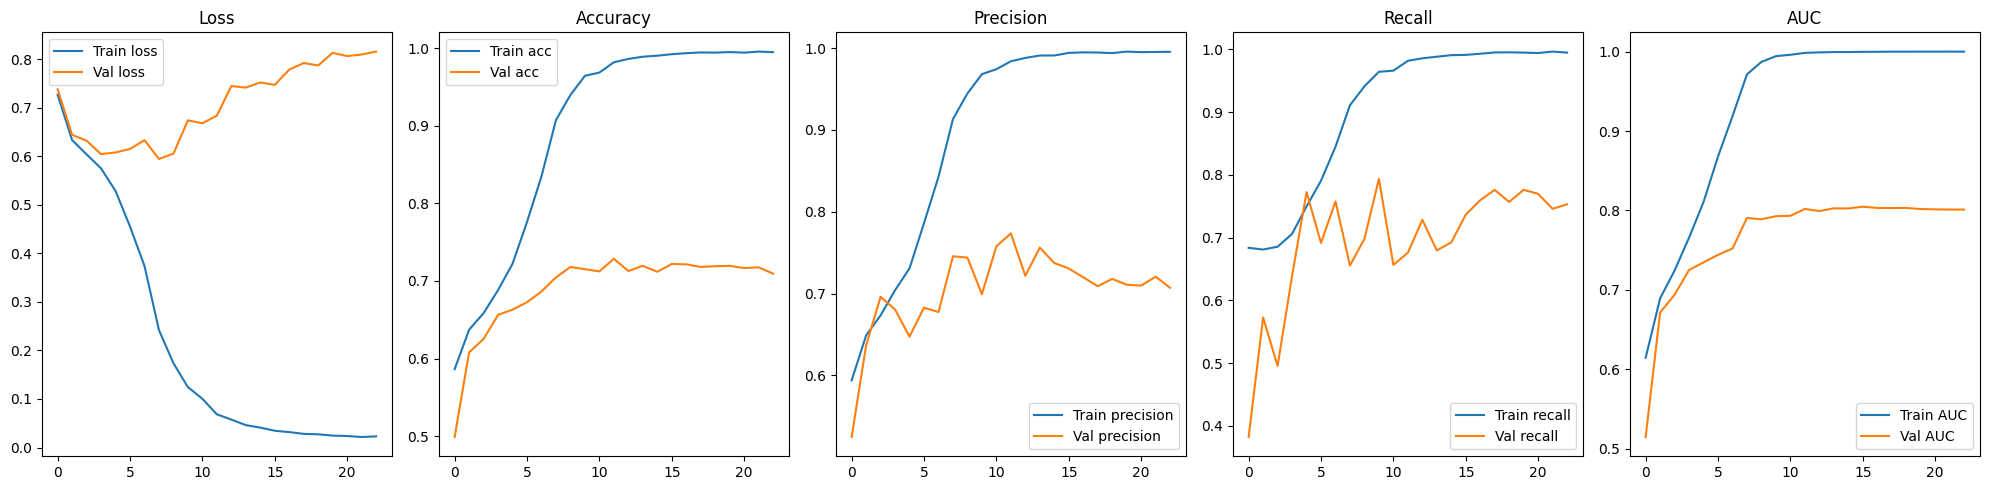

In [ ]:
def plot_history(history):
    fig, ax = plt.subplots(1, 5, figsize=(20, 5))

    # ░░ Row 1 : Train & Val Loss ░░
    ax[0].set_title('Loss')
    ax[0].plot(history.epoch, history.history["loss"], label="Train loss")
    ax[0].plot(history.epoch, history.history["val_loss"], label="Val loss")

    # ░░ Row 1 : Train & Val Accuracy ░░
    ax[1].set_title('Accuracy')
    ax[1].plot(history.epoch, history.history["accuracy"], label="Train acc")
    ax[1].plot(history.epoch, history.history["val_accuracy"], label="Val acc")

    # ░░ Row 1 : Train & Val Precision ░░
    ax[2].set_title('Precision')
    ax[2].plot(history.epoch, history.history["precision"], label="Train precision")
    ax[2].plot(history.epoch, history.history["val_precision"], label="Val precision")

    # ░░ Row 1 : Train & Val Recall ░░
    ax[3].set_title('Recall')
    ax[3].plot(history.epoch, history.history["recall"], label="Train recall")
    ax[3].plot(history.epoch, history.history["val_recall"], label="Val recall")

    # ░░ Row 1 : Train & Val AUC ░░
    ax[4].set_title('AUC')
    ax[4].plot(history.epoch, history.history["auc"], label="Train AUC")
    ax[4].plot(history.epoch, history.history["val_auc"], label="Val AUC")

    for a in ax:
        a.legend()

    plt.tight_layout()
    plt.show()

plot_history(history)

In [ ]:
baseline.evaluate(val_ds)

66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 70ms/step - accuracy: 0.7046 - auc: 0.7906 - loss: 0.5942 - precision: 0.7455 - recall: 0.6556


[0.5942368507385254,
 0.7046433687210083,
 0.745549738407135,
 0.6556169390678406,
 0.7906093001365662]

# ===================== MODEL BASELINE + DATA AUGMENTATION ======================

In [ ]:
def initialize_augmented_model():
    augmented = Sequential([
        layers.Input(shape=(128,128,3)),
        layers.Rescaling(1./255),

        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.05),
        layers.RandomZoom(0.05),

        layers.Conv2D(32, kernel_size = (4,4), padding="same", strides = (1,1), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPool2D(pool_size=(2,2), padding="same"),

        layers.Conv2D(64, kernel_size = (3,3), padding="same", strides = (1,1), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPool2D(pool_size=(2,2), padding="same"),

        layers.Conv2D(128, kernel_size = (3,3), padding="same", strides = (1,1), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPool2D(pool_size=(2,2), padding="same"),

        layers.Conv2D(256, kernel_size=(3,3), padding="same", activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPool2D(pool_size=(2,2), padding="same"),

        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-5)),
        layers.Dropout(0.4),

        layers.Dense(1, activation="sigmoid")
    ])
    return augmented

In [ ]:
augmented = initialize_augmented_model()
augmented.summary()

Model: "sequential_50"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_52 (Rescaling)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_17 (RandomFlip)     │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_32              │ (None, 128, 128, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_34 (RandomZoom)     │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_190 (Conv2D)             │ (None, 128, 128, 32)   │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_160         │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_190               │ (None, 64, 64, 32)     │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_191 (Conv2D)             │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_161         │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_191               │ (None, 32, 32, 64)     │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_192 (Conv2D)             │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_162         │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_192               │ (None, 16, 16, 128)    │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_193 (Conv2D)             │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_163         │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_193               │ (None, 8, 8, 256)      │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_24     │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_100 (Dense)               │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_50 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_101 (Dense)               │ (None, 1)              │           12

 Total params: 424,033 (1.62 MB)

 Trainable params: 423,073 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
def compile_augmented_model(augmented):
    adam = optimizers.Adam(learning_rate = 1e-4)

    augmented.compile(
        loss = "binary_crossentropy",
        optimizer = adam,
        metrics = ["accuracy", "precision", "recall", AUC(name="auc")]
    )
    return augmented

In [ ]:
%%time

# ░░░░░░░░░░░░░░ Training ░░░░░░░░░░░░░░
augmented = initialize_augmented_model()
augmented = compile_augmented_model(augmented)

ES = EarlyStopping(
    patience=15,
    restore_best_weights=True
)

# ModelCheckpoint to save the best version of our model after every epoch
checkpoint = callbacks.ModelCheckpoint(MODEL_2,
                                            monitor="val_loss",
                                            verbose=0,
                                            save_best_only=True)

# ReduceLROnPlateau to reduce the learning_rate if the model doesn't get better after a few epochs
lr_reducer = callbacks.ReduceLROnPlateau(monitor="val_loss",
                                        factor=0.5,
                                        patience=5,
                                        verbose=1,
                                        min_lr=1e-6)
history_2 = augmented.fit(
    train_ds,
    batch_size=32,
    epochs=10,
    validation_data=val_ds,
    callbacks=[ES, lr_reducer, checkpoint,csv_logger_2],
    verbose = 1
)

Epoch 1/10
CPU times: user 2.23 s, sys: 179 ms, total: 2.4 s
Wall time: 2.37 s


W0000 00:00:1773213954.290497 1865932 op_kernel.cc:1858] OP_REQUIRES failed at whole_file_read_ops.cc:117 : NOT_FOUND: data/image_dataset/edible/Tremella_fuciformis/aug_Tremella_fuciformis39.png; No such file or directory
W0000 00:00:1773213954.290552 1865938 op_kernel.cc:1858] OP_REQUIRES failed at whole_file_read_ops.cc:117 : NOT_FOUND: data/image_dataset/edible/Lentinula_edodes/aug_Lentinula_edodes26.png; No such file or directory
W0000 00:00:1773213954.290595 1865941 op_kernel.cc:1858] OP_REQUIRES failed at whole_file_read_ops.cc:117 : NOT_FOUND: data/image_dataset/edible/Hygrophorus_chrysodon/aug_Hygrophorus_chrysodon22.png; No such file or directory
W0000 00:00:1773213954.290880 1865938 op_kernel.cc:1858] OP_REQUIRES failed at whole_file_read_ops.cc:117 : NOT_FOUND: data/image_dataset/edible/Calbovista_subsculpta/aug_Calbovista_subsculpta18.png; No such file or directory
W0000 00:00:1773213954.291261 1865931 op_kernel.cc:1858] OP_REQUIRES failed at whole_file_read_ops.cc:117 : NO

NotFoundError: Graph execution error:

Detected at node ReadFile defined at (most recent call last):
<stack traces unavailable>
data/image_dataset/edible/Tremella_fuciformis/aug_Tremella_fuciformis39.png; No such file or directory
	 [[{{node ReadFile}}]]
	 [[IteratorGetNext]] [Op:__inference_multi_step_on_iterator_1291391]

In [ ]:
def plot_history(history, history_2):
    fig, ax = plt.subplots(6, 2, figsize=(15, 20))

    # ░░ Row 1 : Train loss ░░
    ax[0][0].set_title('Baseline Train loss')
    ax[0][0].plot(history.epoch, history.history["loss"], label="Baseline Train loss")

    ax[0][1].set_title('Augmented Train loss')
    ax[0][1].plot(history_2.epoch, history_2.history["loss"], label="Augmented Train loss", color="red")

    # ░░ Row 2 : Val loss ░░
    ax[1][0].set_title('Baseline Val loss')
    ax[1][0].plot(history.epoch, history.history["val_loss"], label="Baseline Val loss")

    ax[1][1].set_title('Augmented Val loss')
    ax[1][1].plot(history_2.epoch, history_2.history["val_loss"], label="Augmented Val loss", color="red")

    # ░░ Row 3 : Train accuracy ░░
    ax[2][0].set_title('Baseline Train accuracy')
    ax[2][0].plot(history.epoch, history.history["accuracy"], label="Baseline Train acc")

    ax[2][1].set_title('Augmented Train accuracy')
    ax[2][1].plot(history_2.epoch, history_2.history["accuracy"], label="Augmented Train acc", color="red")

    # ░░ Row 4 : Val accuracy ░░
    ax[3][0].set_title('Baseline Val accuracy')
    ax[3][0].plot(history.epoch, history.history["val_accuracy"], label="Baseline Val acc")

    ax[3][1].set_title('Augmented Val accuracy')
    ax[3][1].plot(history_2.epoch, history_2.history["val_accuracy"], label="Augmented Val acc", color="red")

    # ░░ Row 5 : Train AUC ░░
    ax[4][0].set_title('Baseline Train AUC')
    ax[4][0].plot(history.epoch, history.history["auc"], label="Baseline Train auc")

    ax[4][1].set_title('Augmented Train AUC')
    ax[4][1].plot(history_2.epoch, history_2.history["auc"], label="Augmented Train auc", color="red")

    # ░░ Row 6 : Val AUC ░░
    ax[5][0].set_title('Baseline Val AUC')
    ax[5][0].plot(history.epoch, history.history["val_auc"], label="Baseline Val auc")

    ax[5][1].set_title('Augmented Val AUC')
    ax[5][1].plot(history_2.epoch, history_2.history["val_auc"], label="Augmented Val auc", color="red")

    plt.tight_layout()
    plt.show()

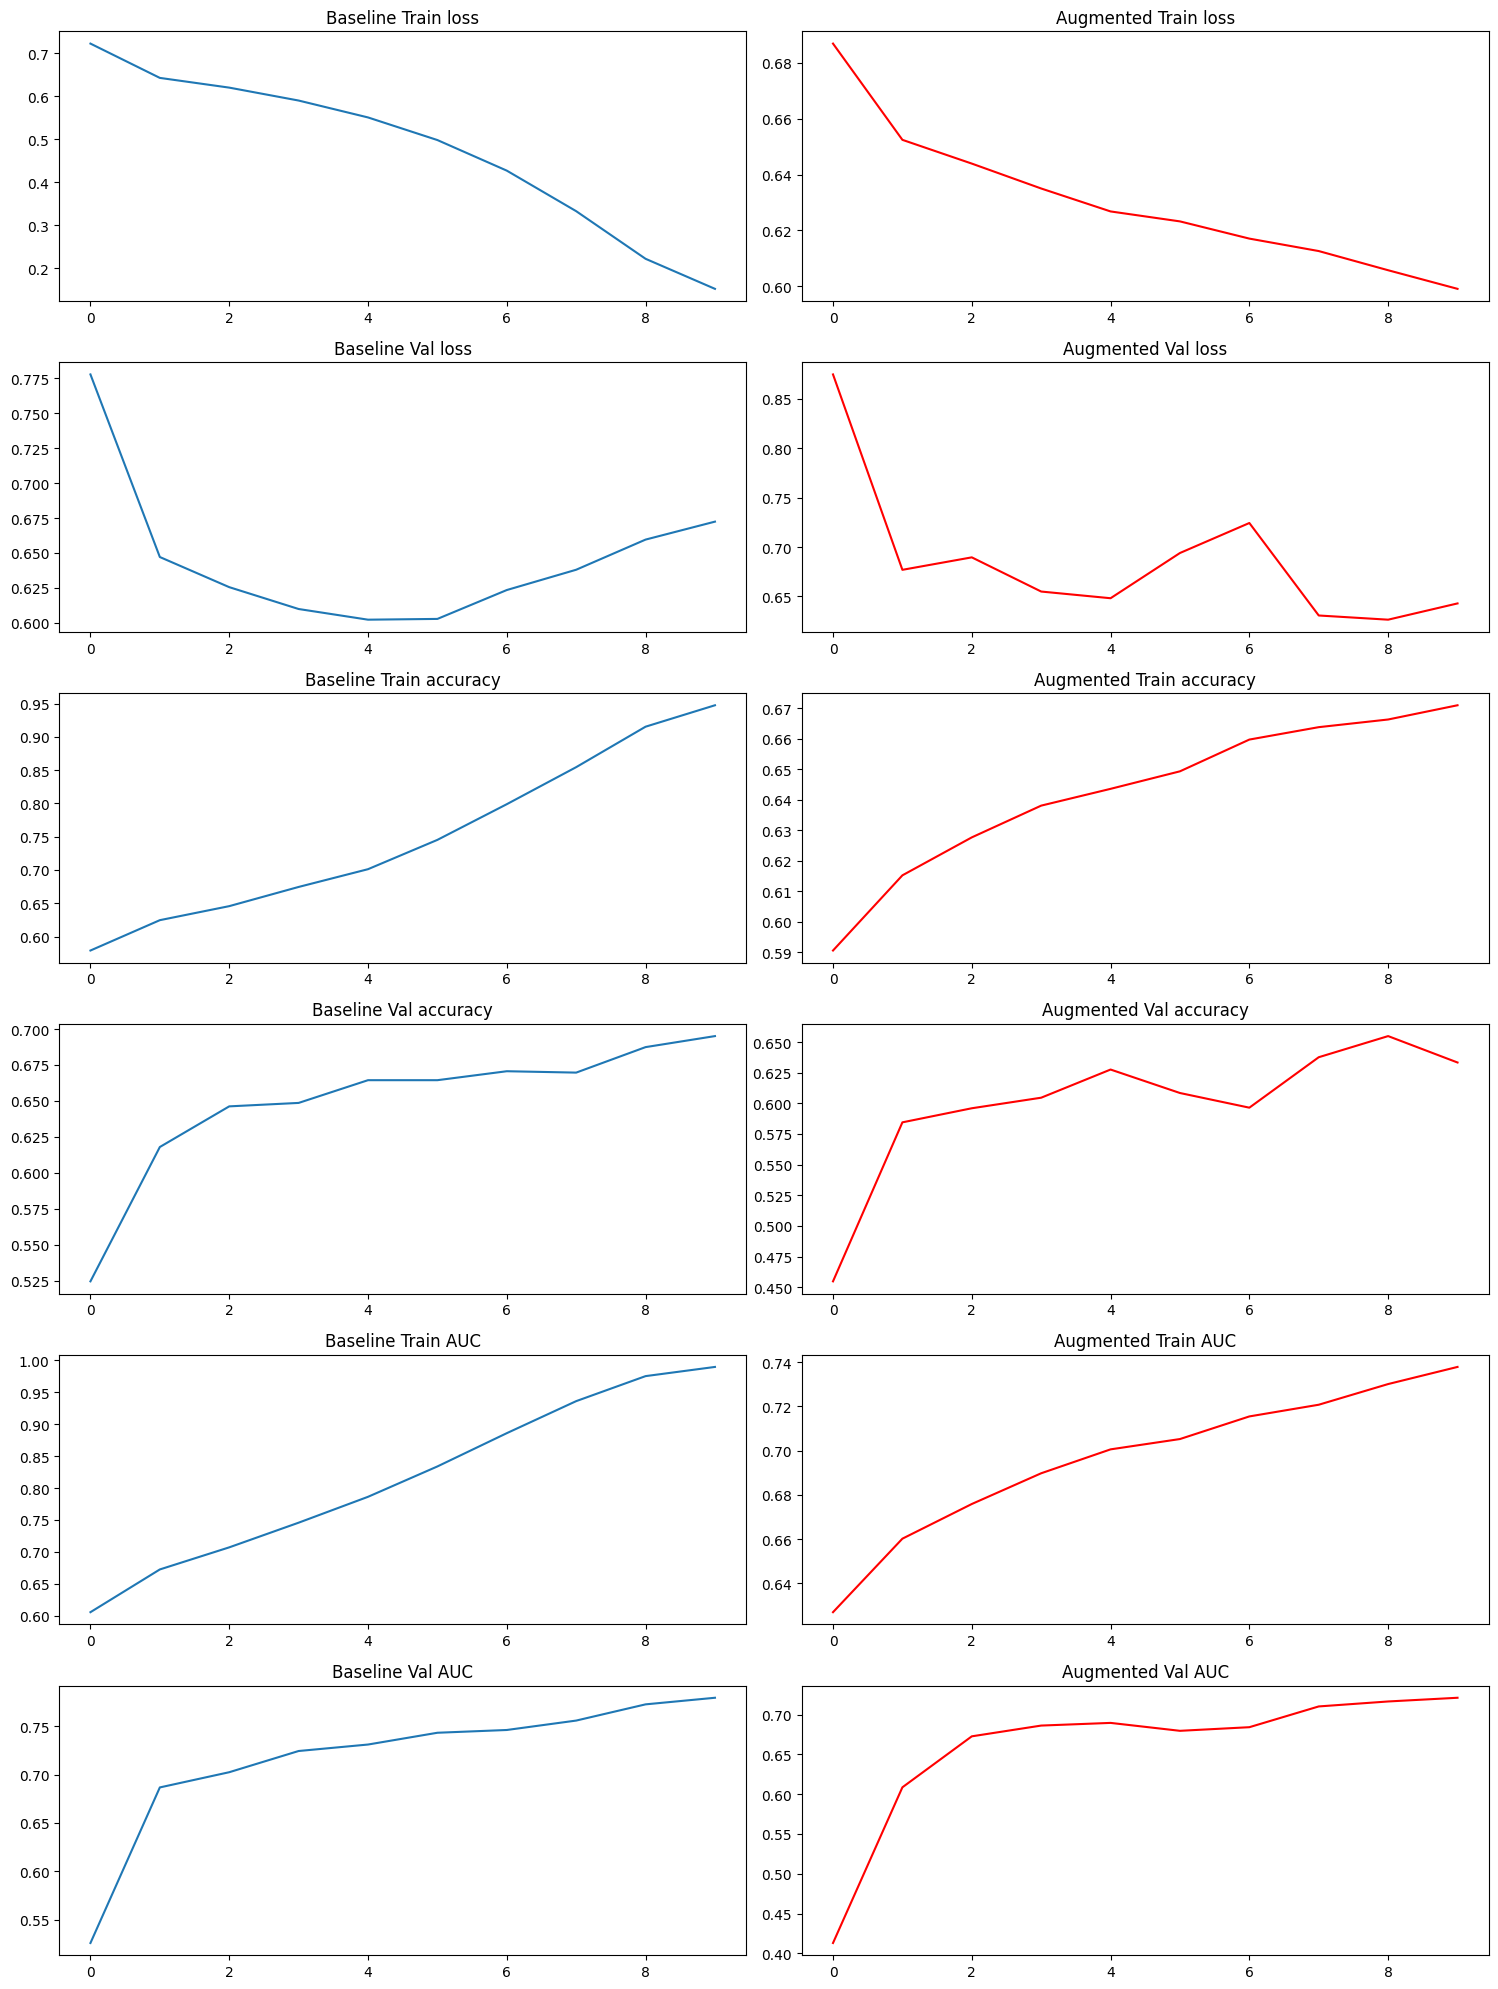

In [ ]:
plot_history(history, history_2)

In [ ]:
display(baseline.evaluate(val_ds), augmented.evaluate(val_ds))

66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.6644 - auc: 0.7313 - loss: 0.6022 - precision: 0.6684 - recall: 0.7035
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.6549 - auc: 0.7166 - loss: 0.6264 - precision: 0.6820 - recall: 0.6298


[0.6022326946258545,
 0.6644327640533447,
 0.668416440486908,
 0.7034990787506104,
 0.7312675714492798]

[0.626401960849762,
 0.6548587679862976,
 0.6819541454315186,
 0.6298342347145081,
 0.7165520191192627]

In [ ]:
# ░░ 🔮 Prediction ░░

preds_base = baseline.predict(val_ds, verbose=0)
preds_augm = augmented.predict(val_ds, verbose=0)

df_prediction = pd.DataFrame({
    "Baseline": preds_base.flatten(),
    "Augmented": preds_augm.flatten(),
})

display(df_prediction.head(10))

,Baseline,Augmented
0,0.637568,0.370774
1,0.297089,0.369654
2,0.591406,0.590266
3,0.382825,0.924524
4,0.235478,0.645637
5,0.235838,0.592429
6,0.359364,0.726201
7,0.656430,0.452659
8,0.802366,0.588261
9,0.402162,0.964238


In [ ]:
# ░░ 🔮 Prediction Label 1 ░░
# if > 0.5 → 1 else → 0

pred_labels = (preds_base > 0.5).astype(int)
pred_labels_2 = (preds_augm > 0.5).astype(int)

display(pred_labels, pred_labels_2)

array([[1],
       [0],
       [1],
       ...,
       [0],
       [0],
       [1]], shape=(2089, 1))

array([[0],
       [0],
       [1],
       ...,
       [1],
       [1],
       [0]], shape=(2089, 1))

In [ ]:
# ░░ 🎨  Let's have something prettier ░░

df_proba_results = pd.DataFrame({
    "Baseline_proba": preds_base.flatten(),
    "Augmented_proba": preds_augm.flatten(),
})

class_map = dict(enumerate(class_names))

df_proba_results["Baseline_label"] = (df_proba_results["Baseline_proba"] > 0.5).astype(int)
df_proba_results["Augmented_label"] = (df_proba_results["Augmented_proba"] > 0.5).astype(int)
df_proba_results["Baseline_class"] = (df_proba_results["Baseline_label"].map(class_map))
df_proba_results["Augmented_class"] = (df_proba_results["Augmented_label"].map(class_map))

df_proba_results.head(10)

df_proba_results.to_csv(f"results/baselines_probability_{timestamp}.csv", index=False)

In [ ]:
# ░░ 💾 Save all results ░░
os.makedirs("results", exist_ok=True)
results = []

# baseline_metrics = baseline.metrics_names
# augmented_metrics = augmented.metrics_names

# baseline_eval = baseline.evaluate(val_ds, return_dict=True)
# augmented_eval = augmented.evaluate(val_ds, return_dict=True)

# results.append({
#     "model": "🧱 baseline",
#     **dict(zip(baseline_metrics, baseline_eval))
# })

# results.append({
#     "model": "💪 augmented",
#     **dict(zip(augmented_metrics, augmented_eval))
# })

baseline_eval = baseline.evaluate(val_ds, return_dict=True)
augmented_eval = augmented.evaluate(val_ds, return_dict=True)

results.append({
    "model": "🧱 baseline",
    **baseline_eval
})

results.append({
    "model": "💪 augmented",
    **augmented_eval
})

df_results = pd.DataFrame(results)
df_results.to_csv(f"results/df_results_eval_{timestamp}.csv", index=False)

display(df_results)

66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - accuracy: 0.7046 - auc: 0.7906 - loss: 0.5942 - precision: 0.7455 - recall: 0.6556


ValueError: You must call `compile()` before using the model.